# Exploratory Data Analysis

Let's run Exploratory Data Analysis on the [Penguins dataset](https://www.kaggle.com/parulpandey/palmer-archipelago-antarctica-penguin-data). The goal of this notebook is to understand the data and the problem we are trying to solve.

Let's start by loading the Penguins dataset and taking a look at the first few rows.

You'll see that the dataset contains the following columns:

1. `species`: The species of a penguin. This is the column we want to predict.
2. `island`: The island where the penguin was found
3. `culmen_length_mm`: The length of the penguin's culmen (bill) in millimeters
4. `culmen_depth_mm`: The depth of the penguin's culmen in millimeters
5. `flipper_length_mm`: The length of the penguin's flipper in millimeters
6. `body_mass_g`: The body mass of the penguin in grams
7. `sex`: The sex of the penguin

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

DATASET = Path("../data/penguins.csv")

penguins = pd.read_csv(DATASET)
penguins.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


Now, let's get the summary statistics for the features in our dataset.


In [2]:
penguins.describe(include="all")

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.000000,342.000000,342.000000,342.000000,334
unique,3,3,NaN,NaN,NaN,NaN,3
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,MALE
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.921930,17.151170,200.915205,4201.754386,NaN
std,NaN,NaN,5.459584,1.974793,14.061714,801.954536,NaN
min,NaN,NaN,32.100000,13.100000,172.000000,2700.000000,NaN
25%,NaN,NaN,39.225000,15.600000,190.000000,3550.000000,NaN
50%,NaN,NaN,44.450000,17.300000,197.000000,4050.000000,NaN
75%,NaN,NaN,48.500000,18.700000,213.000000,4750.000000,NaN


Let's now display the distribution of values for the three categorical columns in our data:

-   `species`: There are 3 species of penguins in the dataset: Adelie (with `152` samples), Gentoo (with `124` samples), and Chinstrap (with `68` samples).
-   `island`: Penguins come from 3 islands: Biscoe (`168` samples), Dream (`124` samples), and Torgersen (`52` samples).
-   `sex`: We have `168` male penguins, `165` female penguins, and `1` penguin with an ambiguous gender (`.`). We'll need to fix this later.


In [3]:
species_distribution = penguins["species"].value_counts()
island_distribution = penguins["island"].value_counts()
sex_distribution = penguins["sex"].value_counts()

print(species_distribution, end="\n\n")
print(island_distribution, end="\n\n")
print(sex_distribution)

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64




Let's replace the ambiguous value in the `sex` column with a `null` value:


In [4]:
penguins["sex"] = penguins["sex"].replace(".", np.nan)

# Let's display the new distribution of the column:
sex_distribution = penguins["sex"].value_counts()
sex_distribution

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

Next, let's check for any missing values in the dataset.


In [5]:
penguins.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Let's get rid of the missing values. For now, we are going to replace the missing values with the most frequent value in the column. Later, we'll use a different strategy to replace missing numeric values.


In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")
penguins.iloc[:, :] = imputer.fit_transform(penguins)

# Let's display again the number of missing values:
penguins.isna().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

Let's visualize the distribution of categorical features.


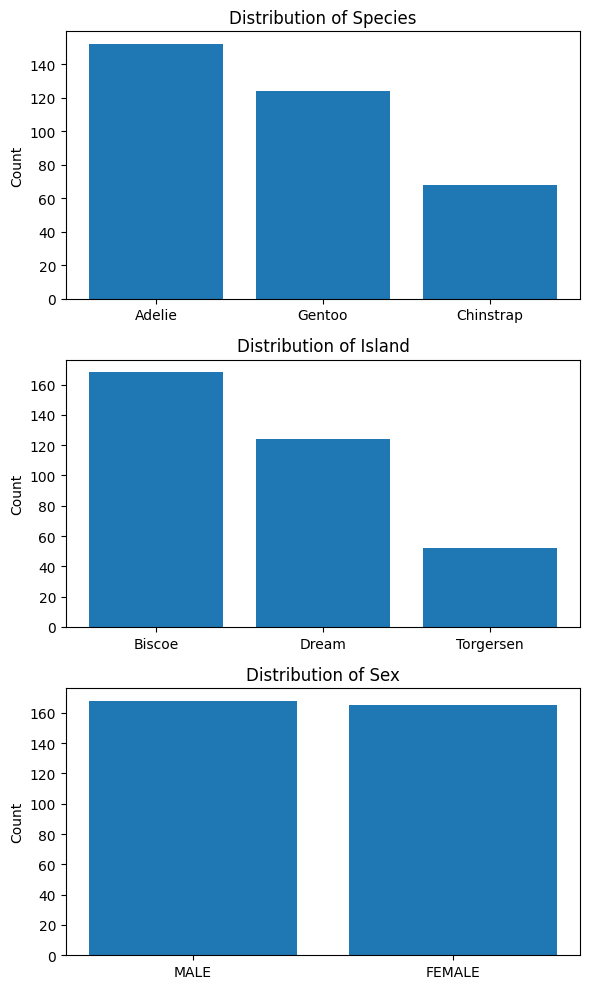

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(6, 10))

axs[0].bar(species_distribution.index, species_distribution.values)
axs[0].set_ylabel("Count")
axs[0].set_title("Distribution of Species")

axs[1].bar(island_distribution.index, island_distribution.values)
axs[1].set_ylabel("Count")
axs[1].set_title("Distribution of Island")

axs[2].bar(sex_distribution.index, sex_distribution.values)
axs[2].set_ylabel("Count")
axs[2].set_title("Distribution of Sex")

plt.tight_layout()
plt.show()

Let's visualize the distribution of numerical columns.


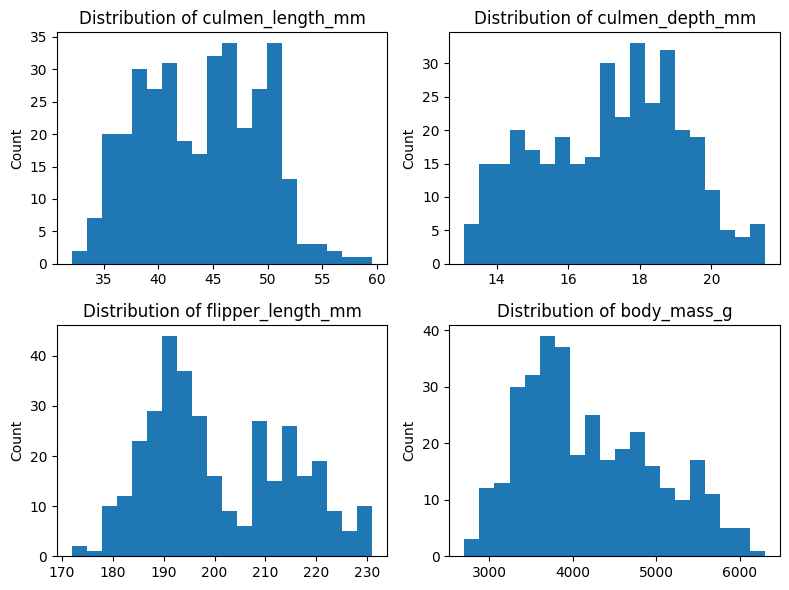

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))

axs[0, 0].hist(penguins["culmen_length_mm"], bins=20)
axs[0, 0].set_ylabel("Count")
axs[0, 0].set_title("Distribution of culmen_length_mm")

axs[0, 1].hist(penguins["culmen_depth_mm"], bins=20)
axs[0, 1].set_ylabel("Count")
axs[0, 1].set_title("Distribution of culmen_depth_mm")

axs[1, 0].hist(penguins["flipper_length_mm"], bins=20)
axs[1, 0].set_ylabel("Count")
axs[1, 0].set_title("Distribution of flipper_length_mm")

axs[1, 1].hist(penguins["body_mass_g"], bins=20)
axs[1, 1].set_ylabel("Count")
axs[1, 1].set_title("Distribution of body_mass_g")

plt.tight_layout()
plt.show()

Let's display the covariance matrix of the dataset. The "covariance" measures how changes in one variable are associated with changes in a second variable. In other words, the covariance measures the degree to which two variables are linearly associated.

Here are three examples of what we get from interpreting the covariance matrix below:

1. The positive covariance of 50.26 between culmen length and flippler length suggests that larger values of culmen length are associated with larger values of flipper length. As one increases, generally so does the other.
2. The positive covariance of 2596.97 between culmen length and body mass suggests that heavier penguins generally have longer culmens. There is a tendency for these two variables to increase together.
3. The negative covariance of -742.66 between culmen depth and body mass suggests a general tendency that penguins with deeper culmens weigh less.


In [9]:
penguins.cov(numeric_only=True)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,29.679415,-2.516984,50.260588,2596.971151
culmen_depth_mm,-2.516984,3.877201,-16.108849,-742.660180
flipper_length_mm,50.260588,-16.108849,197.269501,9792.552037
body_mass_g,2596.971151,-742.660180,9792.552037,640316.716388


Let's now display the correlation matrix. "Correlation" measures both the strength and direction of the linear relationship between two variables:

Here are three examples of what we get from interpreting the correlation matrix below:

1. Penguins that weight more tend to have longer flippers.
2. Penguins with a shallower culmen tend to have longer flippers.
3. Penguins with longer culmens tend to have longer flippers.


In [10]:
penguins.corr(numeric_only=True)

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.000000,-0.234635,0.656856,0.595720
culmen_depth_mm,-0.234635,1.000000,-0.582472,-0.471339
flipper_length_mm,0.656856,-0.582472,1.000000,0.871302
body_mass_g,0.595720,-0.471339,0.871302,1.000000


Let's display the distribution of species by island:


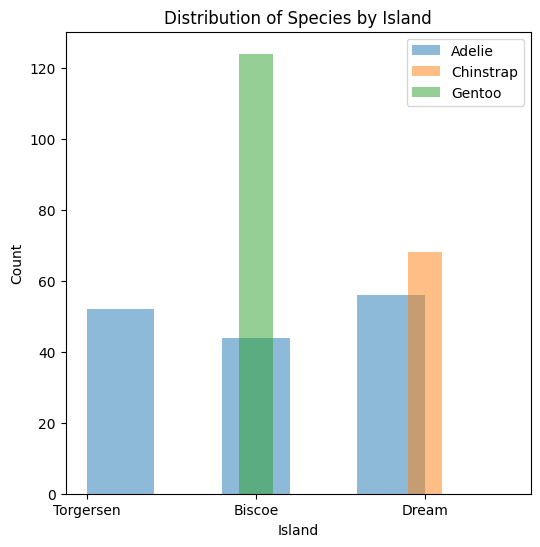

In [11]:
unique_species = penguins["species"].unique()

fig, ax = plt.subplots(figsize=(6, 6))
for species in unique_species:
    data = penguins[penguins["species"] == species]
    ax.hist(data["island"], bins=5, alpha=0.5, label=species)

ax.set_xlabel("Island")
ax.set_ylabel("Count")
ax.set_title("Distribution of Species by Island")
ax.legend()
plt.show()

Let's display the distribution of species by sex.


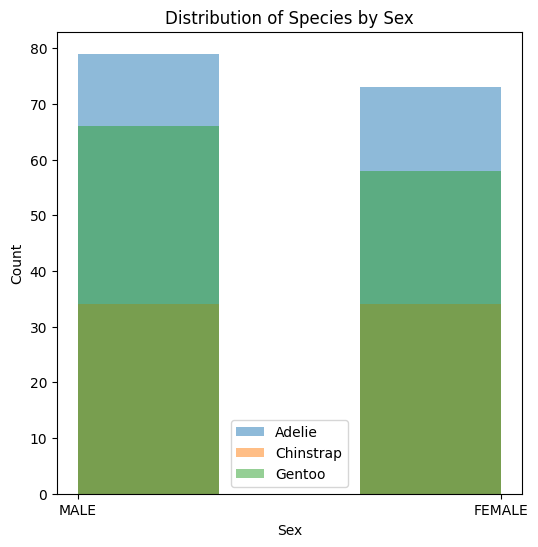

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

for species in unique_species:
    data = penguins[penguins["species"] == species]
    ax.hist(data["sex"], bins=3, alpha=0.5, label=species)

ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.set_title("Distribution of Species by Sex")

ax.legend()
plt.show()

## Assignment: Missing Data Analysis

Let's revisit the original dataset before imputation so we can analyze missing values directly. We'll calculate the percentage of missing values per column, visualize row-level missingness patterns, and inspect how missingness is correlated across columns.


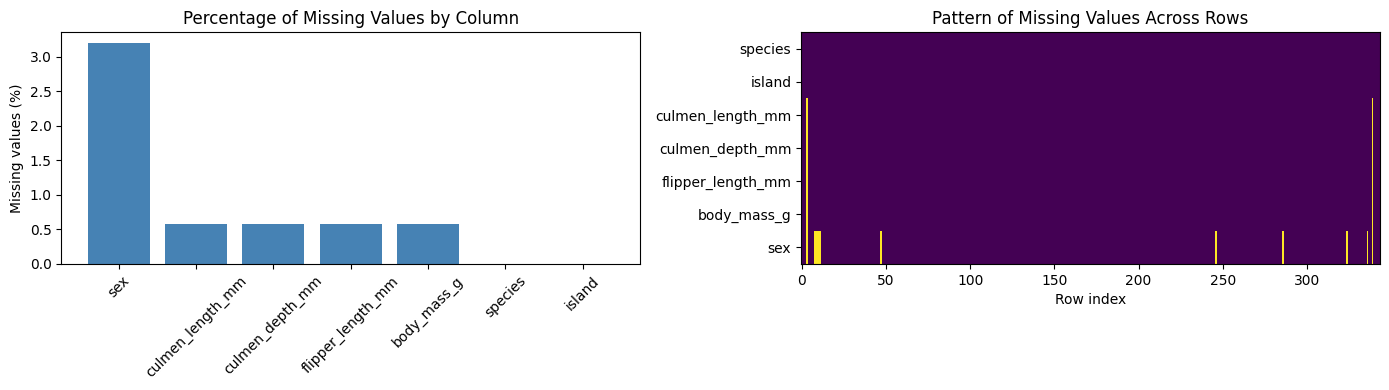

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
culmen_length_mm,1.000000,1.000000,1.000000,1.000000,0.420753
culmen_depth_mm,1.000000,1.000000,1.000000,1.000000,0.420753
flipper_length_mm,1.000000,1.000000,1.000000,1.000000,0.420753
body_mass_g,1.000000,1.000000,1.000000,1.000000,0.420753
sex,0.420753,0.420753,0.420753,0.420753,1.000000


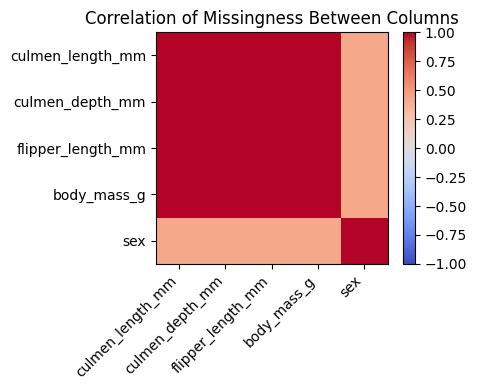

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

penguins_missing = pd.read_csv("../data/penguins.csv")
penguins_missing.loc[penguins_missing["sex"] == ".", "sex"] = np.nan

missing_percent = (
    penguins_missing.isna().mean().mul(100).sort_values(ascending=False)
)
missing_summary = missing_percent.rename("missing_percentage").to_frame()

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].bar(missing_summary.index, missing_summary["missing_percentage"], color="steelblue")
axs[0].set_ylabel("Missing values (%)")
axs[0].set_title("Percentage of Missing Values by Column")
axs[0].tick_params(axis="x", rotation=45)

missing_flags = penguins_missing.isna().astype(int)
axs[1].imshow(missing_flags.T, aspect="auto", interpolation="nearest", cmap="viridis")
axs[1].set_yticks(range(len(missing_flags.columns)))
axs[1].set_yticklabels(missing_flags.columns)
axs[1].set_xlabel("Row index")
axs[1].set_title("Pattern of Missing Values Across Rows")

plt.tight_layout()
plt.show()

missing_columns = penguins_missing.columns[penguins_missing.isna().any()]

if len(missing_columns) > 1:
    missing_corr = penguins_missing[missing_columns].isna().corr()
    display(missing_corr)

    fig, ax = plt.subplots(figsize=(5, 4))
    heatmap = ax.imshow(missing_corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(missing_corr.columns)))
    ax.set_xticklabels(missing_corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(missing_corr.index)))
    ax.set_yticklabels(missing_corr.index)
    ax.set_title("Correlation of Missingness Between Columns")
    fig.colorbar(heatmap, ax=ax)
    plt.tight_layout()
    plt.show()


## Assignment: Numerical Feature Histograms and Outliers

Next, let's study the numerical features in more detail. We'll inspect how histogram shapes change with different bin sizes, identify potential outliers using the interquartile range (IQR) method, and compare the distributions of each feature across penguin species.


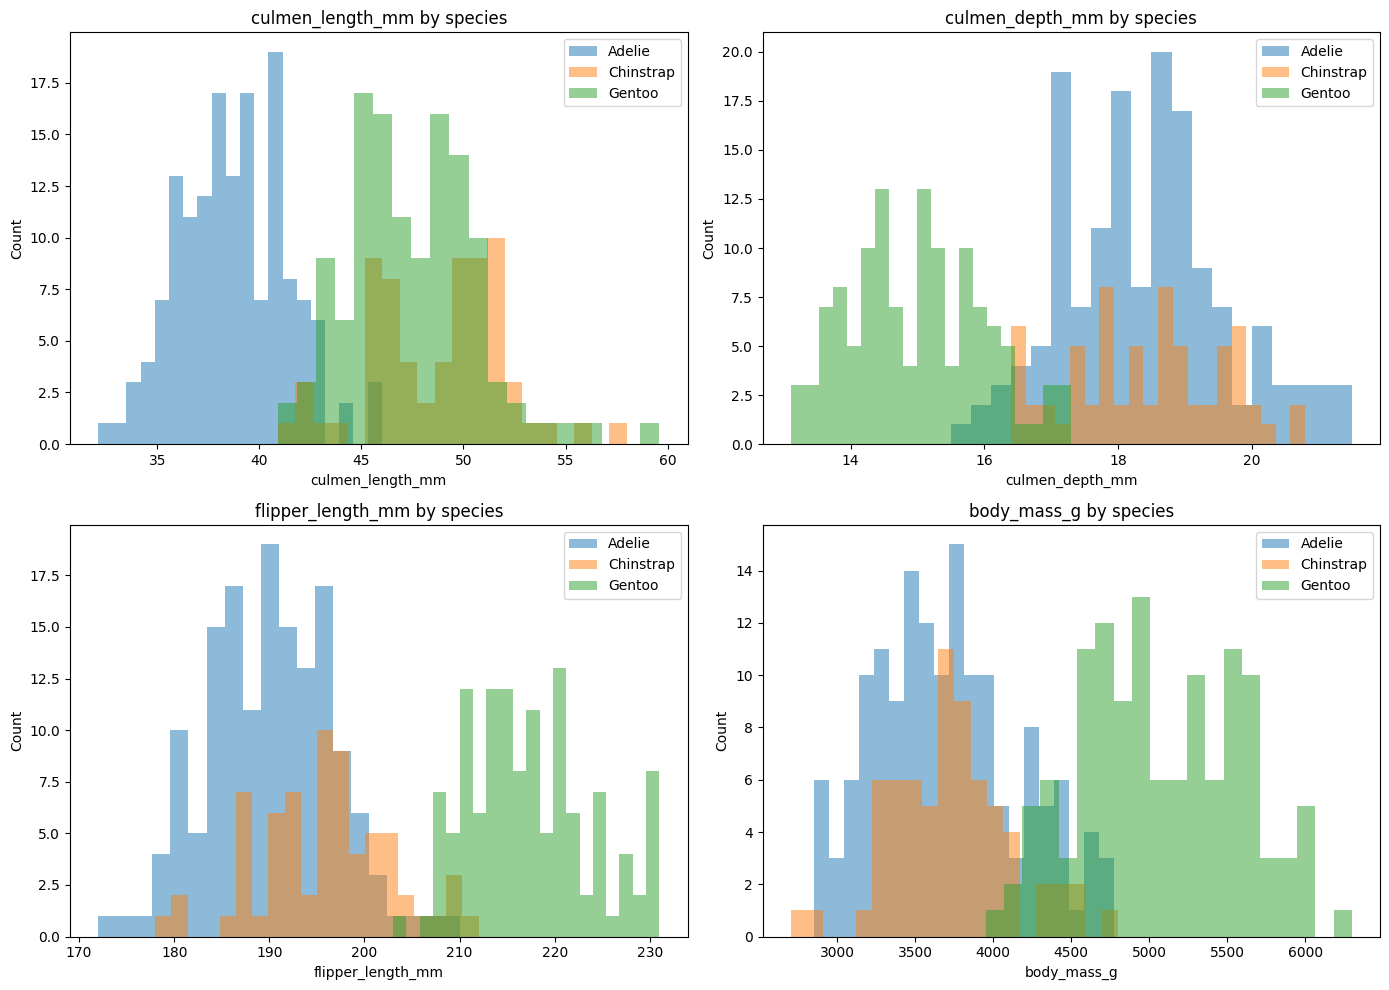

In [12]:
penguins_numeric = pd.read_csv("../data/penguins.csv")
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
bin_sizes = [10, 20, 30]
species_names = sorted(penguins_numeric["species"].dropna().unique())

outlier_rows = []

for feature in numeric_features:
    values = penguins_numeric[feature].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()

    outlier_rows.append(
        {
            "feature": feature,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": int(outlier_count),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for ax, feature in zip(axs, numeric_features):
    for species in species_names:
        species_values = penguins_numeric.loc[
            penguins_numeric["species"] == species, feature
        ].dropna()
        ax.hist(species_values, bins=20, alpha=0.5, label=species)

    ax.set_title(f"{feature} by species")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()


## Assignment: Box Plots by Species

Let's now compare each numerical feature across penguin species using box plots. Box plots make it easier to spot differences in medians, spread, and possible outliers, which helps identify which measurements separate the species most clearly.


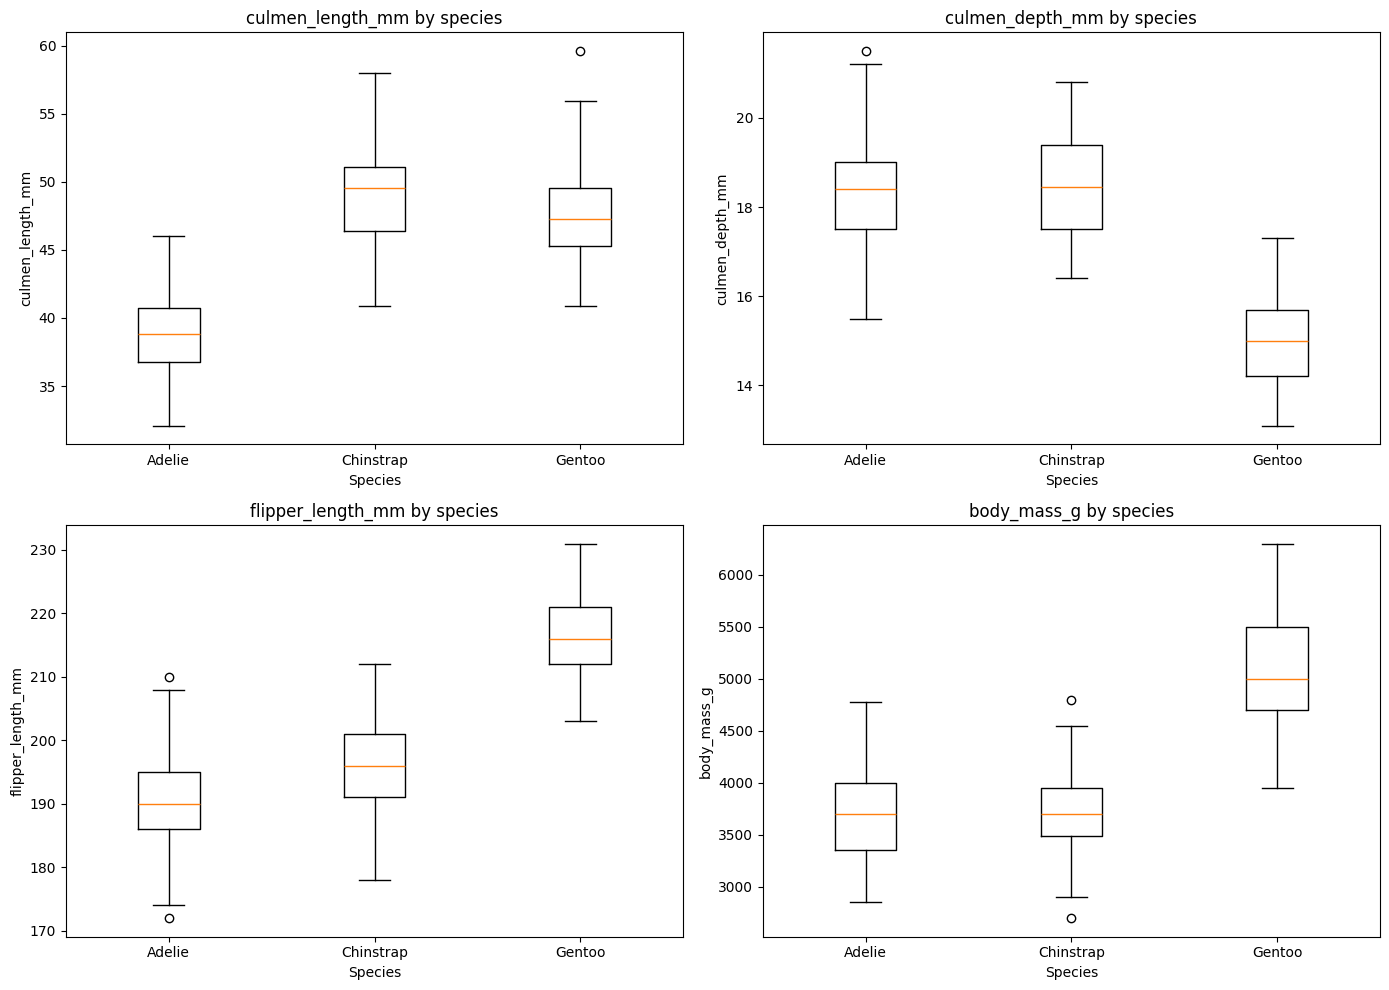

In [16]:
penguins_box = pd.read_csv("../data/penguins.csv")
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
species_names = sorted(penguins_box["species"].dropna().unique())

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for ax, feature in zip(axs, numeric_features):
    feature_groups = [
        penguins_box.loc[penguins_box["species"] == species, feature].dropna()
        for species in species_names
    ]

    ax.boxplot(feature_groups, tick_labels=species_names)
    ax.set_title(f"{feature} by species")
    ax.set_xlabel("Species")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()


## Assignment: Flipper Length and Body Mass Relationship

Now let's investigate how flipper length relates to body mass. A scatter plot helps us see whether penguins with longer flippers also tend to be heavier, and calculating the correlation coefficient for each species lets us quantify that relationship.


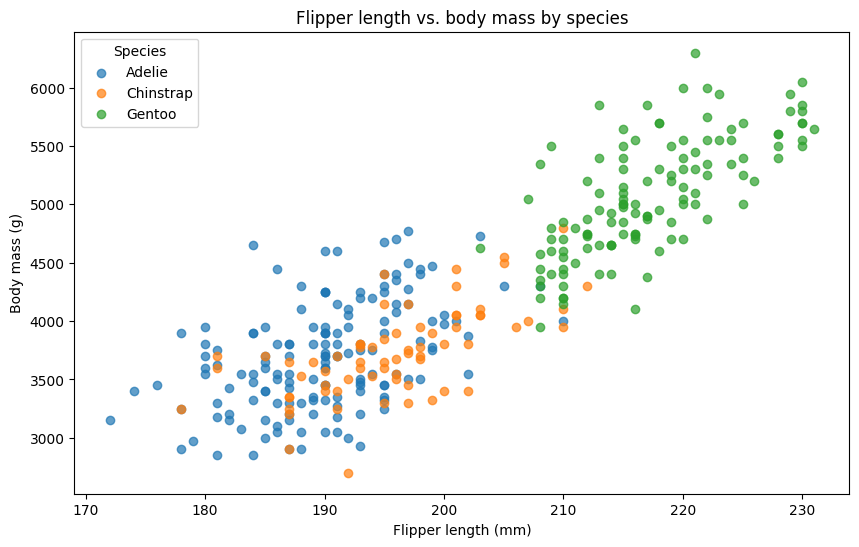

In [20]:
penguins_relationship = pd.read_csv("../data/penguins.csv")

relationship_data = penguins_relationship[
    ["species", "flipper_length_mm", "body_mass_g"]
].dropna()

species_names = sorted(relationship_data["species"].unique())

fig, ax = plt.subplots(figsize=(10, 6))

for species in species_names:
    species_data = relationship_data.loc[
        relationship_data["species"] == species,
        ["flipper_length_mm", "body_mass_g"],
    ]
    ax.scatter(
        species_data["flipper_length_mm"],
        species_data["body_mass_g"],
        alpha=0.7,
        label=species,
    )

ax.set_title("Flipper length vs. body mass by species")
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.legend(title="Species")
plt.show()


## Assignment: Frequency Tables for Categorical Variables

Let's examine how the categorical variables are distributed across one another. We'll build pairwise frequency tables for `species`, `island`, and `sex`, then create a full three-variable count table to see which combinations are common, rare, or missing.


In [21]:
penguins_categorical = pd.read_csv("../data/penguins.csv")
penguins_categorical["sex"] = penguins_categorical["sex"].replace(".", np.nan)
penguins_categorical["sex"] = penguins_categorical["sex"].fillna("Missing")

species_island_table = pd.crosstab(
    penguins_categorical["species"],
    penguins_categorical["island"],
    margins=True,
)
species_island_table

species_sex_table = pd.crosstab(
    penguins_categorical["species"],
    penguins_categorical["sex"],
    margins=True,
)
species_sex_table

island_sex_table = pd.crosstab(
    penguins_categorical["island"],
    penguins_categorical["sex"],
    margins=True,
)
island_sex_table

categorical_combinations = (
    penguins_categorical.groupby(["species", "island", "sex"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)
categorical_combinations


,species,island,sex,count
11,Gentoo,Biscoe,MALE,61
10,Gentoo,Biscoe,FEMALE,58
8,Chinstrap,Dream,FEMALE,34
9,Chinstrap,Dream,MALE,34
3,Adelie,Dream,MALE,28
2,Adelie,Dream,FEMALE,27
5,Adelie,Torgersen,FEMALE,24
6,Adelie,Torgersen,MALE,23
0,Adelie,Biscoe,FEMALE,22
1,Adelie,Biscoe,MALE,22


## Assignment: Overlapping Histograms by Species

This section focuses specifically on comparing species distributions for each numerical feature. By plotting overlapping histograms with shared bin edges, we can see where species overlap strongly and where their measurements separate more clearly.


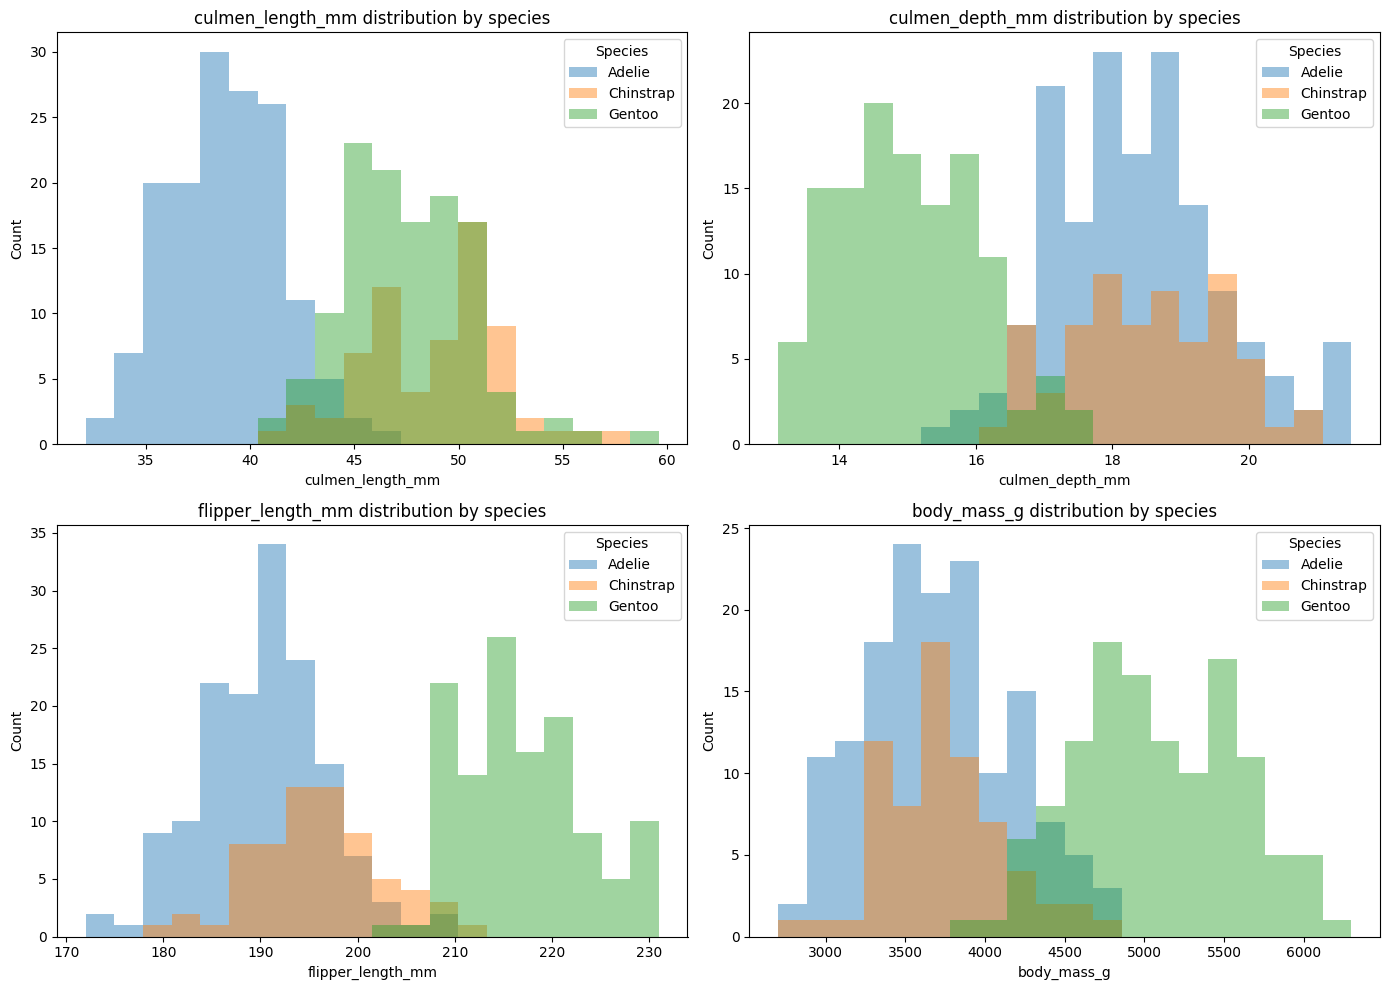

In [22]:
penguins_overlap = pd.read_csv("../data/penguins.csv")
numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]
species_names = sorted(penguins_overlap["species"].dropna().unique())
species_colors = {
    "Adelie": "tab:blue",
    "Chinstrap": "tab:orange",
    "Gentoo": "tab:green",
}

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for ax, feature in zip(axs, numeric_features):
    feature_data = penguins_overlap[feature].dropna()
    bin_edges = np.histogram_bin_edges(feature_data, bins=20)

    for species in species_names:
        species_values = penguins_overlap.loc[
            penguins_overlap["species"] == species,
            feature,
        ].dropna()
        ax.hist(
            species_values,
            bins=bin_edges,
            alpha=0.45,
            label=species,
            color=species_colors.get(species),
        )

    ax.set_title(f"{feature} distribution by species")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.legend(title="Species")

plt.tight_layout()
plt.show()
